In [1]:
import os
print(os.getcwd())

/media/drive/daniela/Projects/clf_Financial_transacction/notebooks


In [15]:
!pip install scikit-learn -q

## Imports

In [2]:
import pandas as pd 
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
import nltk
from nltk.corpus import stopwords
import re



In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/umy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
# Set seed for reproducibility
np.random.seed(42)

## Data Exploring and cleaning

In [5]:
pwd

'/media/drive/daniela/Projects/clf_Financial_transacction/notebooks'

In [6]:
raw_data_train = pd.read_csv('../data/raw/train_transactions.csv', sep=",")

In [7]:
raw_data_train.head()

,transaction_text,category
0,Uber ride INR 48648 TXNde8842f7,travel
1,Flipkart order INR 14678 TXN17584829,shopping
2,Home loan EMI INR 44398 TXN8962c016,emi
3,Netflix subscription INR 38748 TXNdce4ee96,entertainment
4,Hospital bill INR 2002 TXNb7e25951,healthcare


In [8]:
raw_data_train.shape

(5000, 2)

In [9]:
raw_data_train["category"].nunique()

9

In [10]:
raw_data_train["category"].unique()


array(['travel', 'shopping', 'emi', 'entertainment', 'healthcare',
       'investment', 'utilities', 'food', 'education'], dtype=object)

In [11]:
raw_data_train["category"].value_counts()

category
education        602
healthcare       570
travel           565
entertainment    557
utilities        554
shopping         546
emi              541
food             534
investment       531
Name: count, dtype: int64

In [12]:
raw_data_train.isnull().sum()

transaction_text    0
category            0
dtype: int64

In [13]:
raw_data_train['transaction_text'].duplicated().sum()

np.int64(0)

In [14]:
# Print type of column transaction_text
print(raw_data_train['transaction_text'].dtype)

object


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
raw_data_train['category_encoded'] = le.fit_transform(raw_data_train['category'])

# Show the mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:")
for cat, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"  {code} -> {cat}")

print()
raw_data_train[['category', 'category_encoded']].head(10)

Label mapping:
  0 -> education
  1 -> emi
  2 -> entertainment
  3 -> food
  4 -> healthcare
  5 -> investment
  6 -> shopping
  7 -> travel
  8 -> utilities



,category,category_encoded
0,travel,7
1,shopping,6
2,emi,1
3,entertainment,2
4,healthcare,4
5,travel,7
6,entertainment,2
7,investment,5
8,investment,5
9,shopping,6


In [16]:
raw_data_train['category_encoded'].value_counts()

category_encoded
0    602
4    570
7    565
2    557
8    554
6    546
1    541
3    534
5    531
Name: count, dtype: int64

#### Category distribution

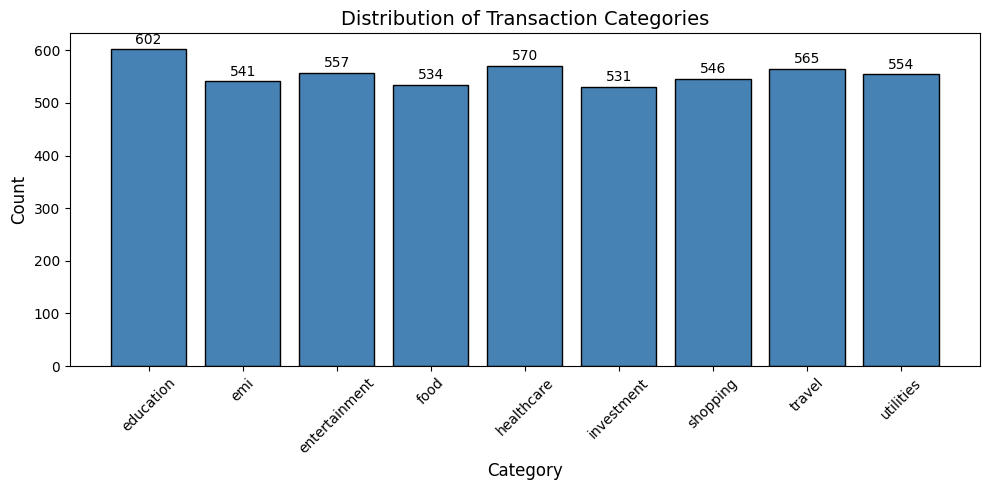

In [17]:

fig, ax = plt.subplots(figsize=(10, 5))

counts = raw_data_train['category'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black')

ax.set_title('Distribution of Transaction Categories', fontsize=14)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
## length of transaction text
lengths = raw_data_train['transaction_text'].apply(len)
# plt.figure(figsize=(10,5))
# lengths.plot(kind='hist', bins=50)
# plt.show()

In [19]:
print("mean length:", lengths.mean())
print("median length:", lengths.median())
print("max length:", lengths.max())
print("min length:", lengths.min())

mean length: 38.2366
median length: 37.0
max length: 48
min length: 27


## Data splitting

### Data split

In [20]:
X = raw_data_train.drop(columns=['category', 'category_encoded'])
y = raw_data_train['category_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
X_train.head()

,transaction_text
4227,Stock purchase INR 6078 TXN6039a851
4676,Food court payment INR 48460 TXN99976250
800,Game purchase INR 34664 TXN7c6e1994
3671,Mutual fund SIP INR 9455 TXN3c6906ac
4193,Hospital bill INR 37349 TXN6a4a60c0


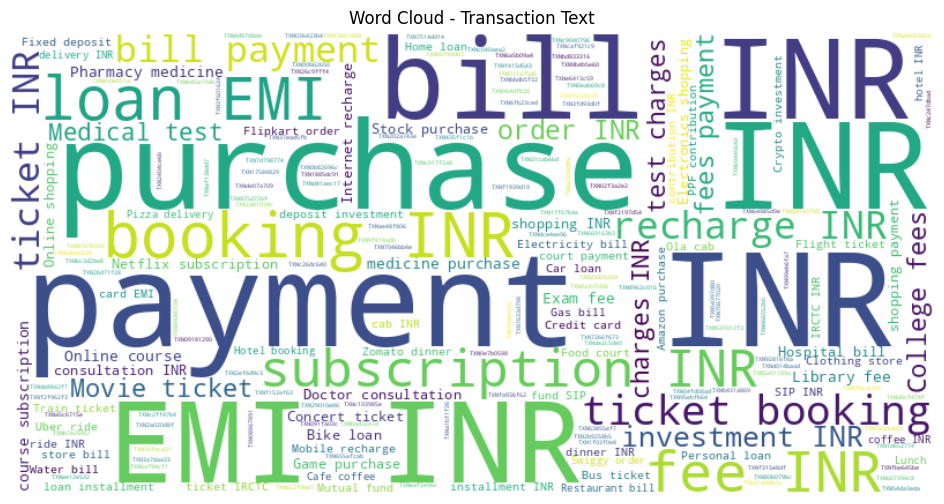

In [22]:
## Word Cloud for Transaction Text

text = ' '.join(raw_data_train['transaction_text'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Transaction Text')
plt.show()

In [23]:
raw_data_train.head()

,transaction_text,category,category_encoded
0,Uber ride INR 48648 TXNde8842f7,travel,7
1,Flipkart order INR 14678 TXN17584829,shopping,6
2,Home loan EMI INR 44398 TXN8962c016,emi,1
3,Netflix subscription INR 38748 TXNdce4ee96,entertainment,2
4,Hospital bill INR 2002 TXNb7e25951,healthcare,4


In [24]:
for i in range(20):
    print(f"Transaction {i+1}: {raw_data_train['transaction_text'][i]}")

Transaction 1: Uber ride INR 48648 TXNde8842f7
Transaction 2: Flipkart order INR 14678 TXN17584829
Transaction 3: Home loan EMI INR 44398 TXN8962c016
Transaction 4: Netflix subscription INR 38748 TXNdce4ee96
Transaction 5: Hospital bill INR 2002 TXNb7e25951
Transaction 6: Ola cab INR 15297 TXN7d798774
Transaction 7: Netflix subscription INR 36831 TXN669163b3
Transaction 8: Crypto investment INR 27543 TXN08867891
Transaction 9: PPF contribution INR 38668 TXN3a7daa33
Transaction 10: Amazon purchase INR 49779 TXN8a35fd36
Transaction 11: Credit card EMI INR 22348 TXNde07a709
Transaction 12: Flipkart order INR 14160 TXNae48f806
Transaction 13: Electricity bill payment INR 6128 TXN3fd93d0f
Transaction 14: Hospital bill INR 23576 TXNc040aea2
Transaction 15: Mobile recharge INR 17385 TXN9f819ad0
Transaction 16: Pizza delivery INR 30158 TXN7046bb4e
Transaction 17: Netflix subscription INR 24857 TXN711a75d6
Transaction 18: Hotel booking INR 19263 TXNbad3247d
Transaction 19: Mobile recharge INR 1

### Data preprocessing

In [25]:
# preprocessing 
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, language="english", remove_stopwords=True):
        self.language = language
        self.remove_stopwords = remove_stopwords

    def fit(self, X, y=None):
        self.stop_words_ = set(stopwords.words(self.language))
        return self

    def _process_text(self, text):
        text = "" if text is None else str(text).lower()

        # Replace TXN codes with placeholder
        text = re.sub(r"\btxn[a-z0-9]+\b", "txn_code", text)

        # Replace currency codes with placeholder
        text = re.sub(r"\b(?:inr|usd|eur|gbp|jpy|cny)\b", "currency", text)

        # Replace numbers with placeholder
        text = re.sub(r"\b\d+\b", "amount", text)

        tokens = text.split()
        if self.remove_stopwords:
            tokens = [w for w in tokens if w not in self.stop_words_]
        return " ".join(tokens)

    def transform(self, X):
        check_is_fitted(self, "stop_words_")
        if hasattr(X, "apply"):         # pandas Series
            return X.apply(self._process_text)
        return pd.Series(X).apply(self._process_text)

### Preprocessing data Pipeline

In [26]:
steps = [
    ('preprocessor', TextPreprocessor()),
    ('vectorizer', TfidfVectorizer(max_features=5000)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
]
pipeline = Pipeline(steps)

In [ ]:
param_grid = {
    "preprocessor__remove_stopwords": [True, False],
    "vectorizer__ngram_range": [(1,1), (1,2)],
    "classifier__C": [0.1, 1, 10],
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train["transaction_text"], y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test["transaction_text"])

In [30]:
# print best parameters and estimator 
print("Best Parameters:", grid.best_params_, "\n")
print("Best Estimator:", grid.best_estimator_)

Best Parameters: {'classifier__C': 0.1, 'preprocessor__remove_stopwords': True, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 1)} 

Best Estimator: Pipeline(steps=[('preprocessor', TextPreprocessor()),
                ('vectorizer', TfidfVectorizer(max_features=5000)),
                ('classifier',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42))])


In [31]:
# Model evaluation
log_report = classification_report(y_test, y_pred, target_names=le.classes_)
print("Classification Report:\n", log_report)

Classification Report:
                precision    recall  f1-score   support

    education       1.00      1.00      1.00       127
          emi       1.00      1.00      1.00       100
entertainment       1.00      1.00      1.00        98
         food       1.00      1.00      1.00        95
   healthcare       1.00      1.00      1.00       115
   investment       1.00      1.00      1.00       114
     shopping       1.00      1.00      1.00       106
       travel       1.00      1.00      1.00       138
    utilities       1.00      1.00      1.00       107

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000



#### Data visualization with t-SNE

In [ ]:
from sklearn.manifold import TSNE

# Extract intermediate transformation from the fitted pipeline
preprocessor = best_model.named_steps['preprocessor']
vectorizer = best_model.named_steps['vectorizer']

X_preprocessed = preprocessor.transform(X_train["transaction_text"])
X_train_transformed = vectorizer.transform(X_preprocessed)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_transformed.toarray())

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_train, palette='tab10')
plt.title('Transaction visualization with t-SNE')
plt.legend(title='Category', labels=le.classes_)
plt.show()